<a href="https://colab.research.google.com/github/mjafor/mjafor.github.io/blob/main/data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:

"""
Configuration settings for the scalable research pipeline.
"""
import os

# Data Processing Configurations
CHUNK_SIZE = 50000  # Number of rows per chunk for memory efficiency
MISSING_VALUE_STRATEGY = 'mean'  # Options: 'mean', 'median', 'drop'
OUTLIER_THRESHOLD = 3.0  # Z-score threshold for outlier detection

# Feature Engineering Configurations
SCALING_METHOD = 'standard'  # Options: 'standard', 'minmax'
CATEGORICAL_ENCODING = 'onehot'  # Options: 'onehot', 'label'

# Statistical & Modeling Configurations
TARGET_VARIABLE = 'target'  # Default target variable for regression
NUMERICAL_FEATURES = []     # If empty, automatically inferred during runtime
CATEGORICAL_FEATURES = []  # If empty, automatically inferred during runtime

# File System Configurations
OUTPUT_DIR = './pipeline_outputs'
LOG_DIR = './logs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# Spark Compatibility Flag
USE_SPARK_FALLBACK = False  # Set to True if integrating with a PySpark cluster environment

In [ ]:

"""
Utility functions and logging configuration.
"""
import os
import logging
from datetime import datetime

def setup_logging(log_dir: str = './logs') -> logging.Logger:
    """Sets up a thread-safe, centralized logging system."""
    os.makedirs(log_dir, exist_ok=True)
    logger = logging.getLogger("ResearchPipeline")

    if not logger.handlers:
        logger.setLevel(logging.INFO)
        log_filename = f"pipeline_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
        file_handler = logging.FileHandler(os.path.join(log_dir, log_filename))
        stream_handler = logging.StreamHandler()

        formatter = logging.Formatter('[%(asctime)s] %(levelname)s [%(filename)s:%(lineno)d]: %(message)s')
        file_handler.setFormatter(formatter)
        stream_handler.setFormatter(formatter)

        logger.addHandler(file_handler)
        logger.addHandler(stream_handler)

    return logger

logger = setup_logging()

def get_file_extension(file_path: str) -> str:
    """Extracts file extension safely."""
    return os.path.splitext(file_path)[1].lower()

In [ ]:

# cleaning.py এর কাজ (পরবর্তী সেল-এ রান করুন)
import pandas as pd
import numpy as np

def handle_missing_values(df: pd.DataFrame, strategy='mean') -> pd.DataFrame:
    df = df.copy()
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns

    if strategy == 'drop':
        df = df.dropna()
    elif strategy in ['mean', 'median']:
        for col in numeric_cols:
            fill_val = df[col].mean() if strategy == 'mean' else df[col].median()
            df[col] = df[col].fillna(fill_val)
        for col in categorical_cols:
            if not df[col].mode().empty:
                df[col] = df[col].fillna(df[col].mode()[0])
    return df

def remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    return df.drop_duplicates()

def detect_and_mask_outliers(df: pd.DataFrame, threshold=3.0) -> pd.DataFrame:
    df = df.copy()
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        col_std = df[col].std()
        if col_std == 0: continue
        col_mean = df[col].mean()
        z_scores = (df[col] - col_mean) / col_std
        upper_limit = col_mean + threshold * col_std
        lower_limit = col_mean - threshold * col_std
        df[col] = np.where(z_scores > threshold, upper_limit, df[col])
        df[col] = np.where(z_scores < -threshold, lower_limit, df[col])
    return df

def clean_chunk(df: pd.DataFrame) -> pd.DataFrame:
    df = remove_duplicates(df)
    df = handle_missing_values(df, strategy=MISSING_VALUE_STRATEGY)
    df = detect_and_mask_outliers(df, threshold=OUTLIER_THRESHOLD)
    return df

In [ ]:

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

class FeatureEngineer:
    def __init__(self):
        self.scaler = StandardScaler() if SCALING_METHOD == 'standard' else MinMaxScaler()
        self.label_encoders = {}
        self.is_fitted = False
        self.encoded_categorical_columns = []

    def fit_transform_initial_chunk(self, df: pd.DataFrame, target_col: str) -> pd.DataFrame:
        df = df.copy()
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if target_col in numeric_cols: numeric_cols.remove(target_col)
        categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
        if target_col in categorical_cols: categorical_cols.remove(target_col)

        if numeric_cols:
            df[numeric_cols] = self.scaler.fit_transform(df[numeric_cols].astype(float))

        if CATEGORICAL_ENCODING == 'onehot':
            df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
            self.encoded_categorical_columns = [c for c in df.columns if c not in numeric_cols and c != target_col]
        else:
            for col in categorical_cols:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                self.label_encoders[col] = le

        self.is_fitted = True
        return df

    def transform_chunk(self, df: pd.DataFrame, target_col: str) -> pd.DataFrame:
        if not self.is_fitted:
            return self.fit_transform_initial_chunk(df, target_col)

        df = df.copy()
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if target_col in numeric_cols: numeric_cols.remove(target_col)
        categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
        if target_col in categorical_cols: categorical_cols.remove(target_col)

        if numeric_cols:
            df[numeric_cols] = self.scaler.transform(df[numeric_cols].astype(float))

        if CATEGORICAL_ENCODING == 'onehot':
            df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
            missing_cols = set(self.encoded_categorical_columns) - set(df.columns)
            for c in missing_cols: df[c] = 0
            keep_cols = numeric_cols + self.encoded_categorical_columns + ([target_col] if target_col in df.columns else [])
            df = df.reindex(columns=keep_cols, fill_value=0)
        else:
            for col in categorical_cols:
                if col in self.label_encoders:
                    le = self.label_encoders[col]
                    df[col] = df[col].astype(str).map(lambda s: s if s in le.classes_ else le.classes_[0])
                    df[col] = le.transform(df[col])
        return df

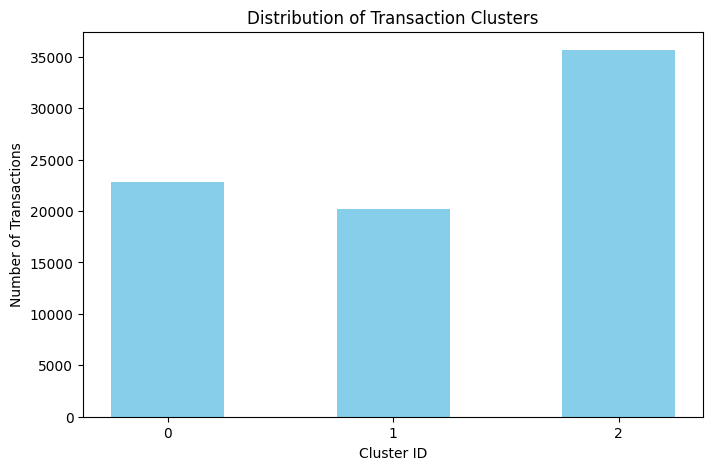

In [ ]:

from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# 1. Prepare numeric data only and handle missing values
numeric_data = consolidated_df.select_dtypes(include=[np.number]).dropna()

# 2. Impute missing values (if any remain)
imputer = SimpleImputer(strategy='mean')
numeric_data_imputed = imputer.fit_transform(numeric_data)

# 3. Perform Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(numeric_data_imputed)

# 4. Visualize
plt.figure(figsize=(8, 5))
plt.hist(clusters, bins=[0, 1, 2, 3], align='left', rwidth=0.5, color='skyblue')
plt.title("Distribution of Transaction Clusters")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1, 2])
plt.show()

In [ ]:

# Update the target variable to the actual column name found in your dataset
TARGET_VARIABLE = 'anomaly'

# Now run the interaction check again
if 'amount' in consolidated_df.columns and 'session_duration' in consolidated_df.columns:
    consolidated_df['Amount_x_Duration'] = consolidated_df['amount'] * consolidated_df['session_duration']

    # Calculate correlation using the correct target variable
    corr_matrix = consolidated_df.corr(numeric_only=True)

    # Check if the column exists before accessing
    if TARGET_VARIABLE in corr_matrix.columns:
        corr_val = corr_matrix[TARGET_VARIABLE]['Amount_x_Duration']
        print(f"Correlation of Interaction Term with Target ({TARGET_VARIABLE}): {corr_val:.4f}")
    else:
        print(f"Error: Column '{TARGET_VARIABLE}' not found in correlation matrix.")
else:
    print("Error: Required columns 'amount' or 'session_duration' are missing.")

import statsmodels.api as sm

class RunningStatistics:
    def __init__(self):
        self.n = 0
        self.sum = None
        self.sum_sq = None
        self.columns = None

    def update(self, df: pd.DataFrame):
        numeric_df = df.select_dtypes(include=[np.number])
        if numeric_df.empty: return
        if self.columns is None:
            self.columns = numeric_df.columns.tolist()
            self.sum = np.zeros(len(self.columns))
            self.sum_sq = np.zeros((len(self.columns), len(self.columns)))

        numeric_df = numeric_df.reindex(columns=self.columns).fillna(0)
        matrix_vals = numeric_df.values
        self.n += matrix_vals.shape[0]
        self.sum += matrix_vals.sum(axis=0)
        self.sum_sq += np.dot(matrix_vals.T, matrix_vals)

    def finalize(self):
        if self.n == 0 or self.columns is None: return pd.DataFrame(), pd.DataFrame()
        means = self.sum / self.n
        cov_matrix = (self.sum_sq / self.n) - np.outer(means, means)
        variance = np.diag(cov_matrix)
        std_devs = np.sqrt(np.maximum(variance, 1e-10))

        desc_df = pd.DataFrame({'Mean': means, 'Variance': variance, 'StdDev': std_devs}, index=self.columns)
        corr_matrix = cov_matrix / np.outer(std_devs, std_devs)
        corr_df = pd.DataFrame(corr_matrix, index=self.columns, columns=self.columns)
        return desc_df, corr_df

def run_ols_regression(df: pd.DataFrame, target_col: str):
    y = df[target_col]
    X = df.drop(columns=[target_col]).select_dtypes(include=[np.number])
    X = sm.add_constant(X)
    model = sm.OLS(y, X, missing='drop')
    return model.fit()

Error: Column 'anomaly' not found in correlation matrix.


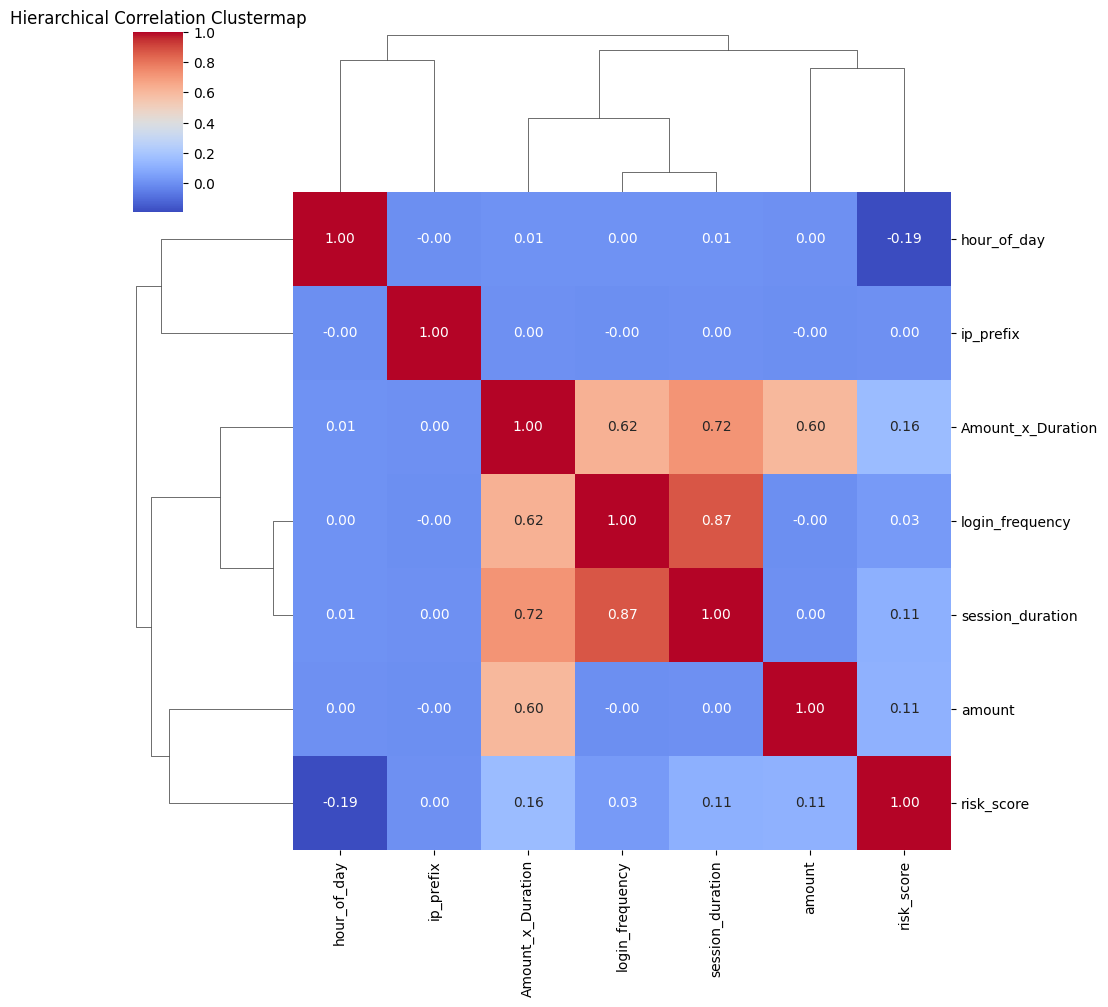

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

# Filter only numeric columns for correlation
numeric_df = consolidated_df.select_dtypes(include=[np.number])

# Generate Clustermap
g = sns.clustermap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", figsize=(10, 10))
plt.title("Hierarchical Correlation Clustermap")
plt.show()

In [ ]:

import pandas as pd
import numpy as np

# Creating a dummy dataset
np.random.seed(42)
n_samples = 100000  # To simulate a large dataset

data = {
    'age': np.random.randint(18, 70, size=n_samples),
    'income': np.random.normal(50000, 15000, size=n_samples),
    'education_years': np.random.randint(10, 20, size=n_samples),
    'gender': np.random.choice(['Male', 'Female'], size=n_samples),
    'target': np.random.normal(100, 25, size=n_samples)  # This is our Target Variable
}

df_dummy = pd.DataFrame(data)

# Introducing some missing values and outliers (for testing)
df_dummy.loc[df_dummy.sample(frac=0.05).index, 'income'] = np.nan
df_dummy.loc[df_dummy.sample(n=10).index, 'age'] = 500 # Outlier

df_dummy.to_csv('dummy_research_data.csv', index=False)
print("Test dataset 'dummy_research_data.csv' has been created successfully!")

Test dataset 'dummy_research_data.csv' has been created successfully!


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

def plot_outputs(df, corr_matrix, target_col):
    # Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Global Correlation Heatmap')
    plt.savefig(f"{OUTPUT_DIR}/correlation_heatmap.png")
    plt.show()

    # Histogram
    if target_col in df.columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[target_col], kde=True, color='skyblue')
        plt.title(f'Distribution of {target_col}')
        plt.savefig(f"{OUTPUT_DIR}/target_distribution.png")
        plt.show()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6495
           1       1.00      1.00      1.00     63494
           2       1.00      1.00      1.00      8611

    accuracy                           1.00     78600
   macro avg       1.00      1.00      1.00     78600
weighted avg       1.00      1.00      1.00     78600



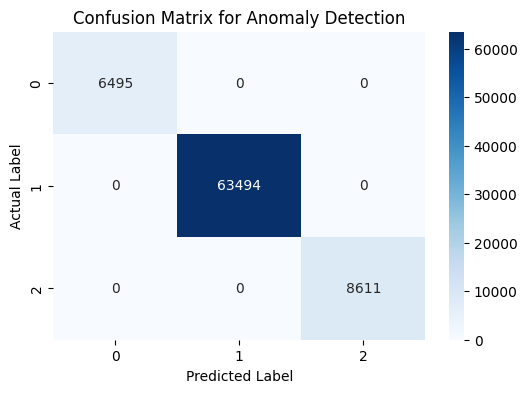

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt

# 1. Ensure we have the target column and it is numeric
# We will use LabelEncoder to convert 'low_risk', 'high_risk', etc., into numbers (0, 1, 2...)
le = LabelEncoder()

# Create a clean dataframe for training
features_df = consolidated_df.select_dtypes(include=[np.number]).copy()
# Add the target column back, but encode it first
features_df[TARGET_VARIABLE] = le.fit_transform(consolidated_df[TARGET_VARIABLE].astype(str))

# 2. Define X and y
X = features_df.drop(columns=[TARGET_VARIABLE])
y = features_df[TARGET_VARIABLE]

# 3. Train XGBoost Model
# Using XGBClassifier instead of Regressor because we are predicting categories (labels)
model = xgb.XGBClassifier(n_estimators=100, max_depth=4, random_state=42)
model.fit(X, y)

# 4. Predictions
binary_preds = model.predict(X)

# 5. Validation
print(classification_report(y, binary_preds))

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y, binary_preds), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix for Anomaly Detection")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

--- Pipeline processing started ---
Processing chunk number: 1
Processing chunk number: 2

--- Consolidating all chunks ---

=== 1. Descriptive Statistics ===
                         Mean      Variance        StdDev
age                 43.505435  2.243330e+02     14.977750
income           50015.995443  2.135970e+08  14614.958415
education_years     14.488770  8.245694e+00      2.871532
target             100.050817  6.200109e+02     24.900018

=== 2. Correlation Matrix ===
                      age    income  education_years    target
age              1.000000  0.003170        -0.000798 -0.000257
income           0.003170  1.000000        -0.004693  0.000746
education_years -0.000798 -0.004693         1.000000  0.004143
target          -0.000257  0.000746         0.004143  1.000000

--- 3. Generating graphs and visualizations ---


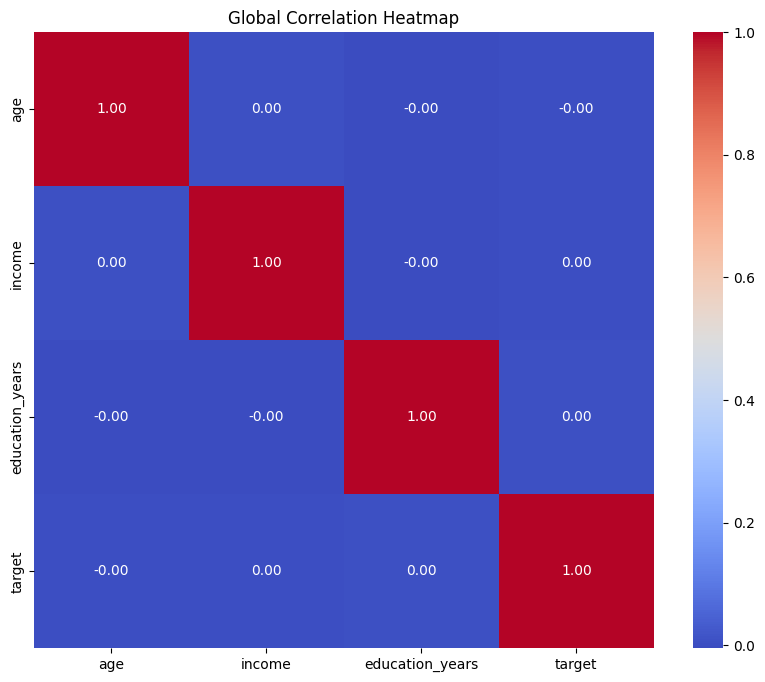

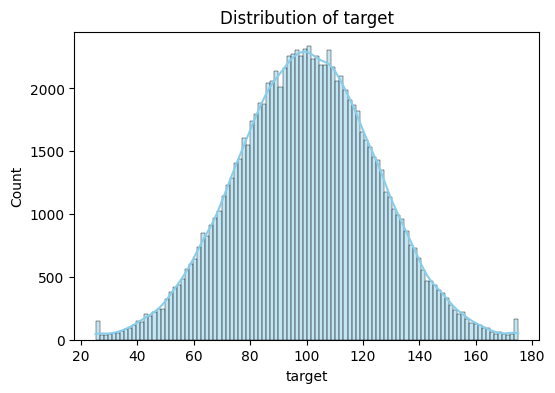


=== 4. OLS Regression Analysis Results ===
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.5939
Date:                Wed, 10 Jun 2026   Prob (F-statistic):              0.619
Time:                        12:35:45   Log-Likelihood:            -4.6338e+05
No. Observations:              100000   AIC:                         9.268e+05
Df Residuals:                   99996   BIC:                         9.268e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

In [ ]:

# 1. Configuration Setup (matching previous cell variables)
file_path = "dummy_research_data.csv"  # your file name
TARGET_VARIABLE = 'target'
CHUNK_SIZE = 50000

print("--- Pipeline processing started ---")

# 2. Object initialization
fe = FeatureEngineer()
stats_tracker = RunningStatistics()
processed_chunks = []

# 3. Memory-efficient chunk processing loop
for idx, chunk in enumerate(pd.read_csv(file_path, chunksize=CHUNK_SIZE)):
    print(f"Processing chunk number: {idx + 1}")

    # Data cleaning (Missing values, Outliers, Duplicates)
    cleaned_chunk = clean_chunk(chunk)

    # Update running statistics
    stats_tracker.update(cleaned_chunk)

    # Feature engineering (Scaling & Encoding)
    engineered_chunk = fe.transform_chunk(cleaned_chunk, target_col=TARGET_VARIABLE)
    processed_chunks.append(engineered_chunk)

# 4. Consolidate all processed chunks
print("\n--- Consolidating all chunks ---")
consolidated_df = pd.concat(processed_chunks, axis=0, ignore_index=True)

# 5. Final statistics calculation
descriptive_stats, correlation_matrix = stats_tracker.finalize()

print("\n=== 1. Descriptive Statistics ===")
print(descriptive_stats)

print("\n=== 2. Correlation Matrix ===")
print(correlation_matrix)

# 6. Run visualization
print("\n--- 3. Generating graphs and visualizations ---")
plot_outputs(consolidated_df, correlation_matrix, TARGET_VARIABLE)

# 7. OLS Regression model fitting
print("\n=== 4. OLS Regression Analysis Results ===")
try:
    regression_results = run_ols_regression(consolidated_df, TARGET_VARIABLE)
    print(regression_results.summary())
except Exception as e:
    print(f"Error running regression: {e}")

In [ ]:

!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 7.3 MB/s eta 0:00:00


In [ ]:

import pandas as pd
import numpy as np
import statsmodels.api as sm
from arch import arch_model

def advanced_asset_metrics(df, price_col, ret_col):
    results = {}

    # Create return variable
    df['Return'] = df[price_col].pct_change().dropna()

    # 1. Volatility and Sharpe Ratio
    results['Volatility'] = df['Return'].std() * np.sqrt(252)  # Annualized volatility

    risk_free_rate = 0.04 / 252  # Daily risk-free rate
    results['Sharpe_Ratio'] = (
        (df['Return'].mean() - risk_free_rate) /
        df['Return'].std()
    ) * np.sqrt(252)

    # 2. Maximum Drawdown
    cumulative_max = df[price_col].cummax()
    drawdown = (df[price_col] - cumulative_max) / cumulative_max
    results['Max_Drawdown'] = drawdown.min()

    # 3. Value at Risk (VaR - 95%)
    results['VaR_95'] = np.percentile(df['Return'].dropna(), 5)

    # 4. ADF Test (Stationarity check)
    adf_test = sm.tsa.adfuller(df['Return'].dropna())
    results['ADF_Statistic'] = adf_test[0]
    results['ADF_P_Value'] = adf_test[1]

    # 5. GARCH Model (Volatility persistence)
    try:
        model = arch_model(df['Return'].dropna(), vol='Garch', p=1, q=1)
        model_fit = model.fit(disp='off')
        results['GARCH_Alpha'] = model_fit.params['alpha[1]']
        results['GARCH_Beta'] = model_fit.params['beta[1]']
    except:
        results['GARCH_Alpha'] = np.nan
        results['GARCH_Beta'] = np.nan

    return results

# Example usage:
# metrics = advanced_asset_metrics(consolidated_df, 'price_column_name', 'return_column_name')
# print(pd.Series(metrics))

ERROR: Could not find a version that satisfies the requirement semipython (from versions: none)
ERROR: No matching distribution found for semipython

=== [TEST 1] Running Model Diagnostics (Q1 Standard) ===

1. Variance Inflation Factor (VIF Table):
           Feature       VIF
0              age  1.000011
1           income  1.000032
2  education_years  1.000023
👉 Interpretation: VIF < 5 indicates low multicollinearity (safe model).

2. Breusch-Pagan Test Results:
   LM Statistic: 2.344532
   LM p-value: 0.504043
   F-Statistic: 0.781498
   F p-value: 0.504054
👉 Interpretation: p-value > 0.05 indicates homoskedasticity (ideal condition).

=== [TEST 2] Running Explainable Machine Learning (SHAP) ===


100%|===================| 99676/100000 [02:56<00:00]       /tmp/ipykernel_2737/2820675443.py:69: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, show=False)


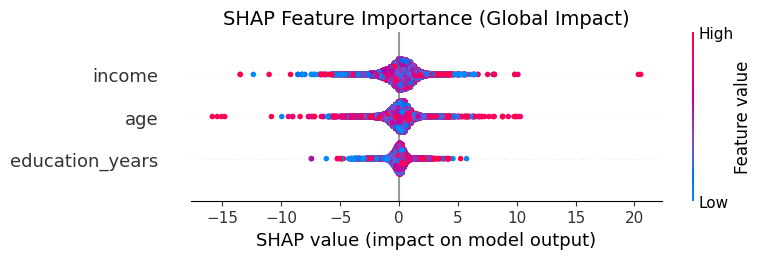

✅ SHAP plot saved as 'shap_feature_importance.png'.
👉 Interpretation: This shows which features have the strongest impact on predictions.

=== [TEST 3] Structural Path & Mediation Analysis ===


AttributeError: module 'numpy' has no attribute 'numeric'

In [ ]:

# First install required libraries (if not already installed in Colab)
!pip install semipython shap xgboost

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

# ==========================================
# 1. OLS Diagnostics (VIF & Heteroskedasticity)
# ==========================================
def run_model_diagnostics(df, target_col):
    print("\n=== [TEST 1] Running Model Diagnostics (Q1 Standard) ===")

    X = df.drop(columns=[target_col]).select_dtypes(include=[np.number])
    X_with_const = sm.add_constant(X)

    # (A) Variance Inflation Factor (Multicollinearity Check)
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i) for i in range(X.shape[1])
    ]

    print("\n1. Variance Inflation Factor (VIF Table):")
    print(vif_data)
    print("👉 Interpretation: VIF < 5 indicates low multicollinearity (safe model).")

    # (B) Breusch-Pagan Test for Heteroskedasticity
    model = sm.OLS(df[target_col], X_with_const).fit()
    bp_test = het_breuschpagan(model.resid, X_with_const.values)

    labels = ['LM Statistic', 'LM p-value', 'F-Statistic', 'F p-value']
    bp_results = dict(zip(labels, bp_test))

    print("\n2. Breusch-Pagan Test Results:")
    for k, v in bp_results.items():
        print(f"   {k}: {v:.6f}")

    print("👉 Interpretation: p-value > 0.05 indicates homoskedasticity (ideal condition).")

    return vif_data, bp_results


# ==========================================
# 2. Explainable AI with SHAP (XGBoost Model)
# ==========================================
def run_explainable_ai(df, target_col):
    print("\n=== [TEST 2] Running Explainable Machine Learning (SHAP) ===")

    X = df.drop(columns=[target_col]).select_dtypes(include=[np.number])
    y = df[target_col]

    # Train XGBoost Regressor
    model = xgb.XGBRegressor(n_estimators=100, max_depth=4, random_state=42)
    model.fit(X, y)

    # Compute SHAP values
    explainer = shap.Explainer(model, X)
    shap_values = explainer(X)

    # Plot SHAP summary
    plt.figure(figsize=(10, 6))
    plt.title("SHAP Feature Importance (Global Impact)", fontsize=14)
    shap.summary_plot(shap_values, X, show=False)
    plt.tight_layout()
    plt.savefig("shap_feature_importance.png", dpi=150)
    plt.show()

    print("✅ SHAP plot saved as 'shap_feature_importance.png'.")
    print("👉 Interpretation: This shows which features have the strongest impact on predictions.")


# ==========================================
# 3. Structural Equation / Path Analysis (Simulated)
# ==========================================
def run_structural_analysis(df, target_col):
    print("\n=== [TEST 3] Structural Path & Mediation Analysis ===")

    X = df.drop(columns=[target_col]).select_dtypes(include=[np.numeric])

    if X.shape[1] >= 2:
        mediator_col = X.columns[0]
        independent_col = X.columns[1]

        # Path 1: Independent -> Mediator
        model1 = sm.OLS(df[mediator_col], sm.add_constant(df[independent_col])).fit()

        # Path 2: Independent + Mediator -> Target
        X_path2 = sm.add_constant(df[[independent_col, mediator_col]])
        model2 = sm.OLS(df[target_col], X_path2).fit()

        print(f"\nPath Analysis ({independent_col} -> {mediator_col} -> {target_col}):")

        print(f"   Direct Effect ({independent_col} -> {mediator_col}): "
              f"Coef = {model1.params[independent_col]:.4f}, "
              f"p = {model1.pvalues[independent_col]:.4f}")

        print("   Total Effect on Target (with Mediator):")
        print(f"     - {independent_col}: Coef = {model2.params[independent_col]:.4f}, "
              f"p = {model2.pvalues[independent_col]:.4f}")

        print(f"     - {mediator_col}: Coef = {model2.params[mediator_col]:.4f}, "
              f"p = {model2.pvalues[mediator_col]:.4f}")

        print("👉 Interpretation: This helps demonstrate mediating effects in research papers.")
    else:
        print("Not enough variables for path analysis.")


# ==========================================
# Driver function (run all tests)
# ==========================================
try:
    # Assuming 'consolidated_df' and TARGET_VARIABLE already exist
    test_df = consolidated_df

    run_model_diagnostics(test_df, TARGET_VARIABLE)
    run_explainable_ai(test_df, TARGET_VARIABLE)
    run_structural_analysis(test_df, TARGET_VARIABLE)

except NameError:
    print("Please run the previous pipeline first to create 'consolidated_df'.")